DIFF 9572.872194918804
WISH 2479726.0727060563
CURR 2470153.2005111375


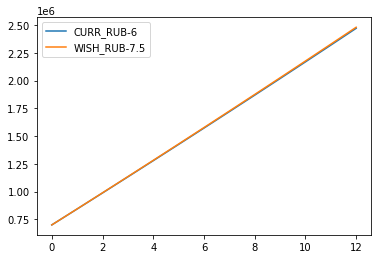

In [10]:
import numpy as np
import matplotlib.pyplot as plt

course = 71.81

def rub_to_usd(rub):
    return rub / (1.03954 * course)


def usd_to_rub(usd):
    return usd * (0.990809 * 71.81)


def predict(initial_balance, rate_percent, duration_month, month_fullfil):
    rate = rate_percent / 100
    balances = [initial_balance]
    for month in duration_month:
        current = balances[len(balances) - 1]
        win = current * (rate * 1 / 12)
        balances.append(current + win + month_fullfil(month))

    return balances


months = [(month + 1) for month in range(12)]

curr_rub_balances = predict(700_000, 6, months, lambda _: 140_000)

freze_rub_balances = np.array(predict(600_000, 7.5, months, lambda _: 0))
add_rub_balances = np.array(predict(100_000, 6, months, lambda _: 140_000))
wish_rub_balances: np.ndarray = freze_rub_balances + add_rub_balances

print('DIFF', wish_rub_balances[len(wish_rub_balances) - 1] - curr_rub_balances[len(curr_rub_balances) - 1])
print('WISH', wish_rub_balances[len(wish_rub_balances) - 1])
print('CURR', curr_rub_balances[len(curr_rub_balances) - 1])

plt.plot([0] + months, curr_rub_balances, label=f'CURR_RUB-{6}')
plt.plot([0] + months, wish_rub_balances, label=f'WISH_RUB-{7.5}')
plt.legend()